In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
from sklearn.datasets import make_classification

In [15]:
X,y=make_classification(n_samples=1000,n_features=2,n_classes=2,n_clusters_per_class=2,n_redundant=0)

In [16]:
X=pd.DataFrame(X)
X.head()

,0,1
0,0.197909,1.001890
1,-0.244818,0.519747
2,-0.522600,-2.175377
3,-0.066295,1.284010
4,-0.857524,-0.840799


In [17]:
y

array([0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1,
       1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0,

<Axes: xlabel='0', ylabel='1'>

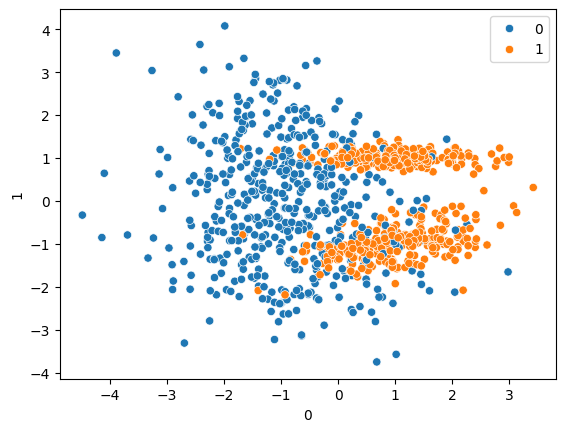

In [18]:
sns.scatterplot(x=X[0],y=X[1],hue=y)

In [19]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [30]:
from sklearn.svm import SVC
svc=SVC(kernel='rbf')

In [31]:
svc.fit(X_train,y_train)

SVC()

In [32]:
y_pred=svc.predict(X_test)

In [33]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,ConfusionMatrixDisplay

In [34]:
print("ACCURACY :",accuracy_score(y_test,y_pred))

ACCURACY : 0.892


              precision    recall  f1-score   support

           0       0.93      0.85      0.89       126
           1       0.86      0.94      0.90       124

    accuracy                           0.89       250
   macro avg       0.89      0.89      0.89       250
weighted avg       0.90      0.89      0.89       250

[[107  19]
 [  8 116]]


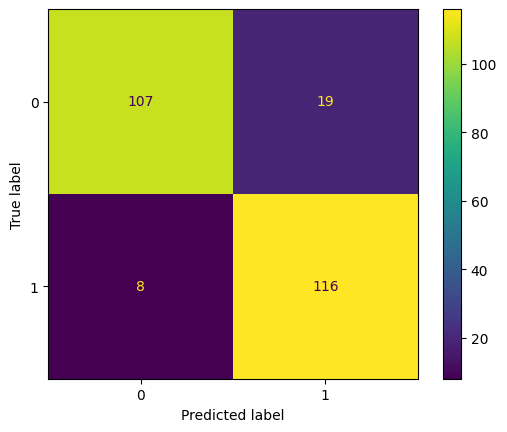

In [35]:
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
disp=ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred))
disp.plot()

ACCURACY : 0.836
              precision    recall  f1-score   support

           0       0.89      0.77      0.83       126
           1       0.79      0.90      0.85       124

    accuracy                           0.84       250
   macro avg       0.84      0.84      0.84       250
weighted avg       0.84      0.84      0.84       250

[[ 97  29]
 [ 12 112]]


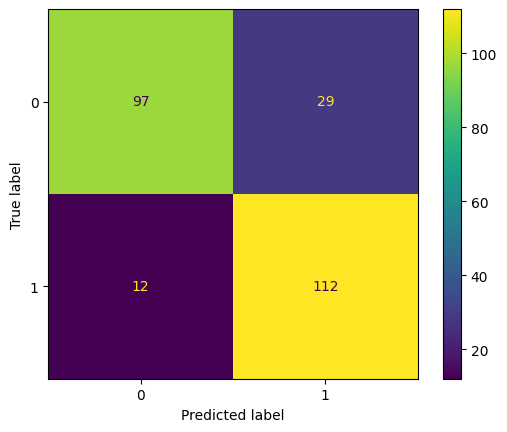

In [37]:
poly=SVC(kernel='poly')
poly.fit(X_train,y_train)
y_pred1=poly.predict(X_test)
print("ACCURACY :",accuracy_score(y_test,y_pred1))
print(classification_report(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
disp=ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred1))
disp.plot()

ACCURACY : 0.824
              precision    recall  f1-score   support

           0       0.84      0.80      0.82       126
           1       0.81      0.85      0.83       124

    accuracy                           0.82       250
   macro avg       0.82      0.82      0.82       250
weighted avg       0.82      0.82      0.82       250

[[101  25]
 [ 19 105]]


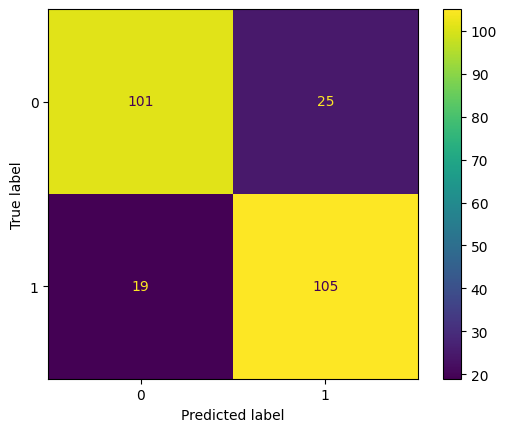

In [38]:
sig=SVC(kernel='sigmoid')
sig.fit(X_train,y_train)
y_pred2=sig.predict(X_test)
print("ACCURACY :",accuracy_score(y_test,y_pred2))
print(classification_report(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
disp=ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred2))
disp.plot()

# HYPERPARAMETER TUNING

I will use RBF

In [40]:
from sklearn.model_selection import GridSearchCV
params={ 'C':[0.1,1,10,100,1000],
        'gamma': [1,0.1,0.01,0.001,0.0001],
        'kernel':['rbf']}

In [41]:
grid=GridSearchCV(SVC(),param_grid=params,refit=True,cv=5,verbose=3)

In [44]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.880 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.920 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.887 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.860 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.873 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.847 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.880 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.860 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.813 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.867 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.853 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             verbose=3)

In [45]:
grid.best_params_

{'C': 1, 'gamma': 1, 'kernel': 'rbf'}

In [46]:
y_pred3=grid.predict(X_test)

In [47]:
print("ACCURACY :",accuracy_score(y_test,y_pred3))

ACCURACY : 0.9


              precision    recall  f1-score   support

           0       0.94      0.86      0.90       126
           1       0.87      0.94      0.90       124

    accuracy                           0.90       250
   macro avg       0.90      0.90      0.90       250
weighted avg       0.90      0.90      0.90       250

[[108  18]
 [  7 117]]


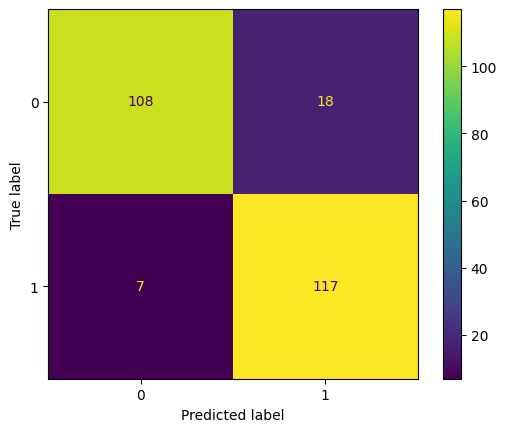

In [48]:
print(classification_report(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
disp=ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred3))
disp.plot()